# Create dataframe that can be applied to treemap package in R.
- Also create barplots to investigate top IMs


In [1]:
from pymodulon.io import *

import os
from os import path

import pandas as pd


import matplotlib.pyplot as plt

## Path to different data

In [2]:
data_dir = path.join('..', 'ctherm_nf','processed_data')
interim_dir = path.join('..', 'ctherm_nf', 'interim')
external_dir = path.join('..', 'ctherm_nf', 'external')

In [3]:
# load the data
ica_data = load_json_model(path.join(data_dir, 'ctherm.json.gz')) #adjusted

/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/pymodulon/util.py:31: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  table = pd.read_json(table)
/Users/skd6150/Applications/anaconda3/envs/modulome_mac/lib/python3.9/site-packages/p

## First rename the imodulon using the imod_rename_mapping.tsv file

In [5]:
df_rename_imod = pd.read_csv('./results_characterize_imodulons/imod_rename_mapping.tsv', sep='\t', index_col=0)

dict_rename_imod = df_rename_imod[['IM']].to_dict()['IM']

In [6]:
df_rename_imod.loc[df_rename_imod.category=='regulatory']

,IM,category,source,f1_Score,pval
IM_num,,,,,
46,TetR_0692,regulatory,GRN,0.969283,1.001081e-231
54,LexA_1449,regulatory,GRN,0.952381,3.142695e-49
7,SigI6,regulatory,NaN,NaN,NaN
42,BlaI_0696,regulatory,NaN,NaN,NaN
56,GlyR3,regulatory,NaN,NaN,NaN
66,Rex_2471,regulatory,NaN,NaN,NaN


In [7]:
# rename all at once
ica_data.rename_imodulons(dict_rename_imod)

In [8]:
# set IM as index for this work
df_rename_imod.set_index('IM', inplace=True)

In [9]:
# GRN for regulation in C. thermocellum
for i,row in ica_data.imodulon_table.iterrows():
    if pd.notnull(row.regulator):
        ica_data.imodulon_table.loc[i, 'category'] = 'regulatory'
    else:
        ica_data.imodulon_table.loc[i, 'category'] = df_rename_imod.loc[i, 'category']

## 1. First create dataframe plotting treemap

In [10]:
# create a dataframe for plotting
df_plot = ica_data.imodulon_table[['explained_variance', 'category']]

df_plot['IM with gene size'] = ''

for idx in df_plot.index.to_list():
    gene_size = str(ica_data.view_imodulon(idx).shape[0])
    df_plot.loc[idx, 'IM with gene size'] = f'{idx} ({gene_size})'

# # reset index
df_plot.reset_index(inplace=True)
df_plot.rename(columns={'index': 'Component (Child)', 'category': 'Category (Parent)'}, inplace=True)

total_variance = df_plot['explained_variance'].sum()
df_plot['variance_pct'] = (df_plot['explained_variance']/total_variance)
print(df_plot['variance_pct'].sum())


df_plot.sort_values('Category (Parent)', inplace=True)

1.0


/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_27861/1618078609.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot['IM with gene size'] = ''
/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_27861/1618078609.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot.rename(columns={'index': 'Component (Child)', 'category': 'Category (Parent)'}, inplace=True)
/var/folders/8c/yy8ts7rn59j58vl5_l6jgcmd1lvs3b/T/ipykernel_27861/1618078609.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

### Save the dataframe to excel, if needed. Otherwise, format it to align with treemap package in R

In [ ]:
# df_plot.to_excel('./results_characterize_imodulons/imodulons_variance_for_treemap_plotting_09132026.xlsx')

## first change the df_plot to the same format as https://github.com/SBRG/modulome_saci/blob/master/data/tree_df_saci.csv
df_plot.rename(columns={'Component (Child)': 'name', 'explained_variance': 'ExplainedVariance', 'Category (Parent)': 'category'}, inplace=True)

df_plot = df_plot[['name', 'category', 'ExplainedVariance']]

#
df_plot.to_csv('./results_characterize_imodulons/imodulons_variance_for_treemap_plotting_09132026.tsv', sep='\t')

## 2. Explained variance code: copied from Rajput et al., 2022 
- (https://github.com/akanksha-r/modulome_paeru2.0/blob/main/notebooks/05_ica_summary.ipynb)

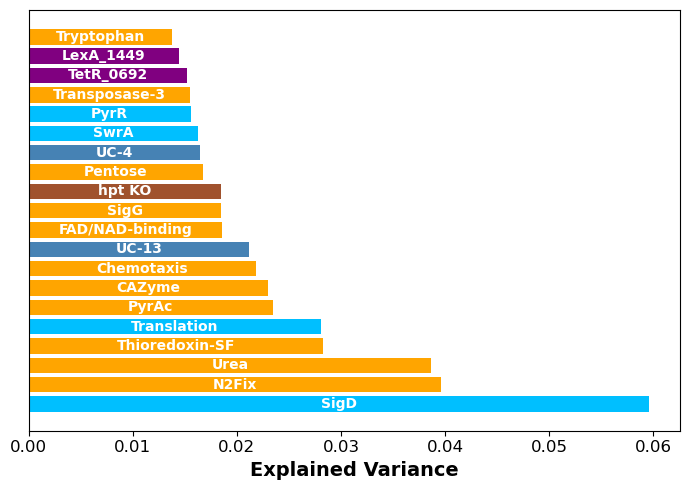

In [ ]:
df_explained_variance_cat = ica_data.imodulon_table[['explained_variance', 'category']].sort_values('explained_variance', ascending=False)

dict_color_categories = {'functional': 'orange',
                         'uncharacterized': 'steelblue',
                         'orthoICA': 'deepskyblue',
                         'single_gene': 'sienna',
                         'regulatory': 'purple'}

fig,ax = plt.subplots(figsize=[7,5])

for idx in df_explained_variance_cat.index.to_list()[0:20]:
    var = df_explained_variance_cat.loc[idx, 'explained_variance']
    category = df_explained_variance_cat.loc[idx, 'category']
    bars = ax.barh(idx, var, color=dict_color_categories[category])

    # put idx text inside the bar (centered horizontally, vertically)
    ax.text(
        x=var / 2,          # middle of the bar in x
        y=idx,              # same y as the bar
        s=str(idx),         # what to show
        va='center',        # vertical alignment
        ha='center',        # horizontal alignment
        color='white',      # text color so it’s visible
        weight='bold',
        fontsize=10
    )

ax.tick_params(axis='x', labelsize=12)
ax.set_xlabel("Explained Variance", fontsize=14, fontweight='bold')

plt.yticks([],fontsize=12)

plt.tight_layout()

# ax.set_title("Explained Variance Plot",fontsize=14)

# save the plot
plt.savefig('./results_characterize_imodulons/variance_explained_top20_ims.png', transparent=True, pad_inches=0.01, dpi=300, format='png')

plt.show()




## FIN